In [54]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import dpluspy

In [61]:
def find_centromere(band_tbl, chrom):
    # find the first position labelled as `acen`
    chrom = str(chrom)
    if chrom.isnumeric():
        chrom = "chr" + chrom
        
    sub_tbl = band_tbl[band_tbl["chrom"] == chrom]
    sub_tbl = sub_tbl[sub_tbl["band"] == "acen"]

    if len(sub_tbl) == 0:
        cen = None
    else:
        cen = int(sub_tbl.iloc[0]["start"])
    return cen


band_tbl = pandas.read_csv("../../data/windows/cytoBand.txt", sep="\t",
    names=["chrom", "start", "end", "stain", "band"])
centromeres = {i: find_centromere(band_tbl, i) for i in range(1, 23)}

In [70]:
chroms = list(range(1, 23))
arms = []
avgs = []
stds = []
nsites = []
maplengths = []

for chrom in range(1, 23):
    mut_fname = f"data/windowed_mutation_maps/scaled_roulette_1kb/map_chr{chrom}.csv.gz"
    map_fname = f"data/recombination_maps/Bherer/sexavg_chr{chrom}.txt.gz"
    rec_map = dpluspy.parsing._load_recombination_map(map_fname, pos_col="pos", map_col="cM")
    mut_df = pandas.read_csv(mut_fname)
    u_vals = np.array(mut_df["mut_map"])
    num_sites = np.array(mut_df["num_sites"])
    starts = np.array(mut_df["chromStart"])

    cen = centromeres[chrom]
    if np.sum(num_sites[starts < cen]) > 1:
        arms.append(f"{chrom}A")
        n = np.sum(num_sites[starts < cen])
        avgs.append(np.nansum(u_vals[starts < cen] * num_sites[starts < cen]) / n)
        stds.append(np.nanstd(u_vals[starts < cen]))
        nsites.append(n)
        maplengths.append(rec_map(cen))
    arms.append(f"{chrom}B")
    n = np.sum(num_sites[starts >= cen])
    avgs.append(np.nansum(u_vals[starts >= cen] * num_sites[starts >= cen]) / n)
    stds.append(np.nanstd(u_vals[starts >= cen]))
    nsites.append(n)
    maplengths.append(rec_map(starts[-1]) - rec_map(cen))

<ErrorbarContainer object of 3 artists>

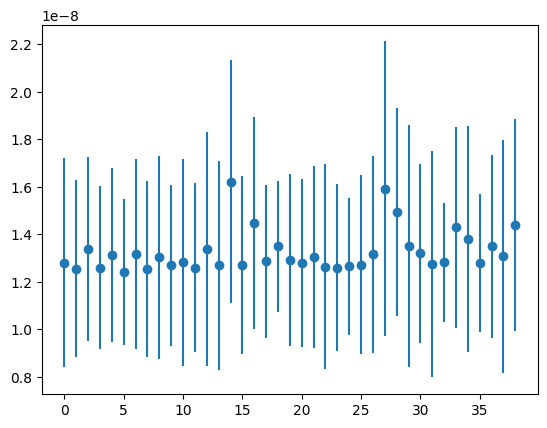

In [71]:
plt.errorbar(range(len(arms)), avgs, yerr=stds, fmt="o")

<ErrorbarContainer object of 3 artists>

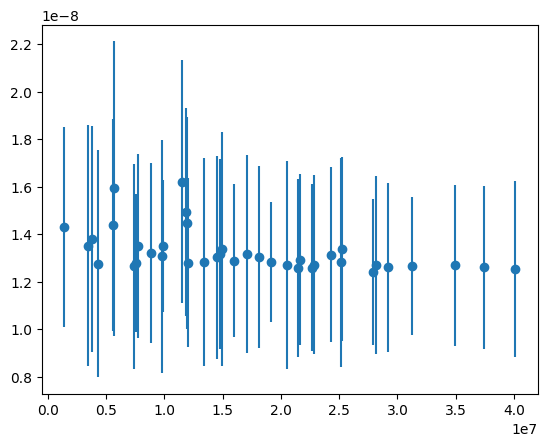

In [72]:
plt.errorbar(nsites, avgs, yerr=stds, fmt="o")

<ErrorbarContainer object of 3 artists>

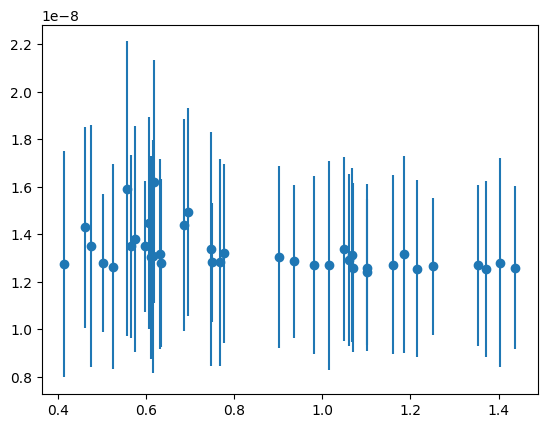

In [73]:
plt.errorbar(maplengths, avgs, yerr=stds, fmt="o")